## **Capstone Project Module 2 - Data Analysis**

# **Latar Belakang**

Perusahaan SaaS yang menjual perangkat lunak penjualan dan pemasaran ke perusahaan lain (B2B) perlu memantau kinerja penjualan secara berkala untuk memastikan pertumbuhan pendapatan sekaligus menjaga profitabilitas. Dalam praktiknya, peningkatan sales tidak selalu berarti keuntungan meningkat karena dapat dipengaruhi oleh komposisi produk yang terjual, perbedaan performa antar segmen pelanggan, wilayah penjualan, serta strategi diskon yang diterapkan. Oleh karena itu, perusahaan membutuhkan analisis berbasis data untuk memahami pola penjualan, mengidentifikasi produk dan segmen yang paling berkontribusi terhadap profit, serta mengevaluasi dampak diskon terhadap margin. Dataset transaksi penjualan yang tersedia dapat digunakan untuk menggali insight mengenai tren sales dan profit dari waktu ke waktu, performa bisnis per region/industry/segment, serta rekomendasi strategi pricing dan diskon yang lebih efektif.

# **Pernyataan Masalah**

Perusahaan membutuhkan pemantauan berbasis data untuk mengidentifikasi pelanggan yang mulai menurun aktivitas transaksinya, karena kondisi ini dapat menjadi sinyal awal risiko tidak melakukan perpanjangan (renewal). Saat ini, perusahaan belum memiliki definisi dan indikator “at-risk” yang jelas dari data transaksi, serta belum mengetahui segmen pelanggan, produk, dan wilayah mana yang cenderung memiliki risiko lebih tinggi. Akibatnya, tim Customer Success/Sales belum dapat memprioritaskan follow-up secara tepat dan tepat waktu. Analisis ini bertujuan membangun indikator early warning berbasis perilaku pembelian, memetakan pola risiko per dimensi bisnis, dan menghasilkan watchlist pelanggan prioritas untuk strategi retensi.

Sebagai seorang *data analyst*, analisis ini akan berfokus untuk menjawab pertanyaan:

**Bagaimana mengidentifikasi pelanggan yang berisiko tidak melakukan renewal lebih awal (at-risk), serta apa karakteristik dan pola transaksinya berdasarkan segmen, wilayah, diskon, dan profit margin?**

# **Data**

Untuk menjawab pertanyaan di atas, kita akan menganalisa data transaksi yang ada. Dataset dapat diakses [di sini](https://www.kaggle.com/datasets/nnthanh101/aws-saas-sales/data). 

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

Dataset ini berisi data transaksi dari sebuah perusahaan SaaS fiktif yang menjual perangkat lunak penjualan dan pemasaran ke perusahaan lain (B2B). Dalam dataset ini, setiap baris merepresentasikan satu produk dalam sebuah transaksi, dan kolom-kolomnya mencakup:

- Row ID: Pengenal unik untuk setiap transaksi.

- Order ID: Pengenal unik untuk setiap pesanan.

- Order Date: Tanggal saat pesanan dibuat.

- Date Key: Representasi numerik dari tanggal pesanan (YYYYMMDD).

- Contact Name: Nama orang yang melakukan pemesanan.

- Country: Negara tempat pesanan dibuat.

- City: Kota tempat pesanan dibuat.

- Region: Wilayah tempat pesanan dibuat.

- Subregion: Subwilayah tempat pesanan dibuat.

- Customer: Nama perusahaan pelanggan yang membuat pesanan.

- Customer ID: Pengenal unik untuk setiap pelanggan.

- Industry: Industri tempat pelanggan tersebut berada.

- Segment: Segmen pelanggan (SMB, Strategic, Enterprise, dll.).

- Product: Produk yang dipesan.

- License: Kunci lisensi untuk produk.

- Sales: Total nilai penjualan untuk transaksi tersebut.

- Quantity: Total jumlah item dalam transaksi tersebut.

- Discount: Diskon yang diterapkan pada transaksi tersebut.

- Profit: Keuntungan dari transaksi tersebut.

In [70]:
# Load Dataset
df = pd.read_csv('SaaS-Sales.csv')
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


In [91]:
print("Shape:", df.shape)

Shape: (9994, 23)


# **Data Understanding and Cleaning**

Sebelum masuk ke dalam analisis, kita perlu mengenal dataset kita lebih jauh dalam tahapan *data understanding*. Dari proses ini, kita akan tahu anomali-anomali apa saja yang terdapat di dalam dataset kita dan perlu ditangani dalam tahapan *data cleaning*. Setiap penangan anomali yang dilakukan, akan disertai dengan justifikasi langkah yang diambil, baik secara *domain knowledge* maupun secara statistik.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Date Key      9994 non-null   int64  
 4   Contact Name  9994 non-null   object 
 5   Country       9994 non-null   object 
 6   City          9994 non-null   object 
 7   Region        9994 non-null   object 
 8   Subregion     9994 non-null   object 
 9   Customer      9994 non-null   object 
 10  Customer ID   9994 non-null   int64  
 11  Industry      9994 non-null   object 
 12  Segment       9994 non-null   object 
 13  Product       9994 non-null   object 
 14  License       9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

In [73]:
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')

Jumlah baris dan kolom di dataset df adalah (9994, 19)


In [74]:
display(df.describe(), df.describe(include='object'))

,Row ID,Date Key,Customer ID,Sales,Quantity,Discount,Profit
count,9994.000000,9.994000e+03,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2.021803e+07,1049.771963,229.858001,3.789574,0.156203,28.656896
std,2885.163629,1.123898e+04,29.719388,623.245101,2.225110,0.206452,234.260108
min,1.000000,2.020010e+07,1001.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2.021052e+07,1024.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2.022063e+07,1049.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2.023052e+07,1076.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2.023123e+07,1101.000000,22638.480000,14.000000,0.800000,8399.976000


,Order ID,Order Date,Contact Name,Country,City,Region,Subregion,Customer,Industry,Segment,Product,License
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,793,48,262,3,12,99,10,3,14,9994
top,EMEA-2023-100111,9/6/2022,Leonard Kelly,United States,London,EMEA,NAMER,Allianz,Finance,SMB,ContactMatcher,16GRM07R1K
freq,14,38,37,2001,922,4219,2507,192,2127,5191,1842,1


In [75]:
pd.set_option('display.max_colwidth', 200)
# data uni di tiap kolom
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,Row ID,9994,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, ..."
1,Order ID,5009,"[EMEA-2022-152156, AMER-2022-138688, EMEA-2021-108966, AMER-2020-115812, EMEA-2023-114412, AMER-2022-161389, APJ-2021-118983, EMEA-2020-105893, EMEA-2020-167164, AMER-2020-143336, AMER-2022-137330..."
2,Order Date,1237,"[11/9/2022, 6/13/2022, 10/11/2021, 6/9/2020, 4/16/2023, 12/6/2022, 11/22/2021, 11/11/2020, 5/13/2020, 8/27/2020, 12/10/2022, 7/17/2023, 9/25/2021, 1/16/2022, 9/17/2021, 10/20/2023, 12/9/2022, 12/2..."
3,Date Key,1237,"[20221109, 20220613, 20211011, 20200609, 20230416, 20221206, 20211122, 20201111, 20200513, 20200827, 20221210, 20230717, 20210925, 20220116, 20210917, 20231020, 20221209, 20211227, 20230911, 20220..."
4,Contact Name,793,"[Nathan Bell, Deirdre Bailey, Zoe Hodges, Thomas Hodges, Adrian Hunter, Adrian Abraham, Emily Morrison, Claire Welch, Carol Campbell, Blake Hughes, Melanie Sharp, Luke Bower, Jonathan Ferguson, Sa..."
5,Country,48,"[Ireland, United States, Germany, Sweden, Canada, Japan, Italy, Turkey, Costa Rica, France, Australia, Luxembourg, Brazil, Philippines, India, United Kingdom, Chile, Spain, South Africa, Portugal,..."
6,City,262,"[Dublin, New York City, Stuttgart, Stockholm, Toronto, Saitama, Naples, Ankara, Los Angeles, San José, Paris, Istanbul, Tokyo, Aichi, Wollongong, Hanover, Luxembourg, Salvador, Davao City, Kolkata..."
7,Region,3,"[EMEA, AMER, APJ]"
8,Subregion,12,"[UKIR, NAMER, EU-WEST, NOR, JAPN, EU, MEA, LATAM, ANZ, APAC, IND, EU-EAST]"
9,Customer,99,"[Chevron, Phillips 66, Royal Dutch Shell, BNP Paribas, Engie, Microsoft, Pfizer, Toyota Motor, Home Depot, Wells Fargo, Carrefour, Costco Wholesale, McKesson, Siemens, Intel, Glencore, Procter & G..."


Secara umum, kita bisa melihat bahwa:

- Ada 9.994 baris data. Setiap baris itu satu catatan transaksi yang unik.
- Ada 5.009 nomor pesanan. Karena baris lebih banyak dari pesanan, berarti satu pesanan bisa berisi beberapa produk.
- Ada 1.237 tanggal berbeda, dan “Date Key” cuma versi angka dari tanggal itu (konsisten).
- Transaksi berasal dari 48 negara dan 262 kota, dikelompokkan ke 3 wilayah besar (EMEA, AMER, APJ) dan 12 subwilayah.
- Datanya mencakup 99 pelanggan, 10 industri, 3 segmen (SMB/Strategic/Enterprise), dan 14 jenis produk.
- `License` hampir selalu unik per baris, jadi lebih cocok dianggap kode, bukan kategori analisis.
- Nilai Sales bervariasi, Quantity variasinya terbatas.
- Discount hanya 12 variasi (mis. 0.2 = 20%).
- Profit ada yang negatif, artinya ada transaksi yang rugi.




**Missing Value**

In [93]:
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values per kolom:")
display(missing)

Missing values per kolom:


Row ID           0
Segment          0
risk_bucket      0
recency_days     0
last_purchase    0
Profit           0
Discount         0
Quantity         0
Sales            0
License          0
Product          0
Industry         0
Order ID         0
Customer ID      0
Customer         0
Subregion        0
Region           0
City             0
Country          0
Contact Name     0
Date Key         0
Order Date       0
is_risk_90+      0
dtype: int64

In [94]:
dup = df.duplicated().sum()
print("Duplicate full rows:", dup)

Duplicate full rows: 0


Order ID boleh berulang karena data ini line-item, bukan duplikat.

In [97]:
# Menampilkan ringkasan struktur data:
# - jumlah baris
# - nama kolom
# - tipe data setiap kolom (datetime, float, int, object)
# - jumlah non-null (untuk mendeteksi missing values setelah konversi)

# Ubah kolom "Order Date" menjadi tipe datetime (tanggal)
# errors="coerce" -> kalau ada nilai yang formatnya tidak valid, akan diubah menjadi NaT (missing datetime)
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")


num_cols = ["Sales", "Profit", "Discount", "Quantity", "Date Key"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Date Key       9994 non-null   int64         
 4   Contact Name   9994 non-null   object        
 5   Country        9994 non-null   object        
 6   City           9994 non-null   object        
 7   Region         9994 non-null   object        
 8   Subregion      9994 non-null   object        
 9   Customer       9994 non-null   object        
 10  Customer ID    9994 non-null   int64         
 11  Industry       9994 non-null   object        
 12  Segment        9994 non-null   object        
 13  Product        9994 non-null   object        
 14  License        9994 non-null   object        
 15  Sales          9994 n

In [98]:
# cek anomali pada data
checks = {
    "Order Date NaT": int(df["Order Date"].isna().sum()), # ada tanggal yang gagal dikonversi (format salah) → harusnya 0.
    "Sales < 0": int((df["Sales"] < 0).sum()), # penjualan negatif biasanya tidak masuk akal (kecuali ada konsep refund/return).
    "Sales = 0": int((df["Sales"] == 0).sum()), # transaksi bernilai nol (bisa aneh, perlu dicek).
    "Quantity <= 0": int((df["Quantity"] <= 0).sum()), # jumlah barang nol/negatif biasanya tidak valid.
    "Discount < 0": int((df["Discount"] < 0).sum()), # diskon negatif tidak masuk akal.
    "Discount > 1": int((df["Discount"] > 1).sum()), # diskon lebih dari 100% (kalau diskon skala 0–1).
    "Profit < 0 (rugi)": int((df["Profit"] < 0).sum()), # ini bukan “error” wajib, tapi anomali bisnis (transaksi rugi) yang perlu dicatat karena relevan untuk analisis margin/diskon.
}
pd.DataFrame(checks, index=["count"]).T

,count
Order Date NaT,0
Sales < 0,0
Sales = 0,0
Quantity <= 0,0
Discount < 0,0
Discount > 1,0
Profit < 0 (rugi),1871


Hasil `df.isna().sum()` dan `df.duplicated().sum()` menunjukkan tidak ada nilai kosong (missing/null) maupun duplikasi baris pada dataset. Selain itu, pengecekan nilai tidak wajar seperti **Sales/Quantity** negatif atau nol serta **Discount di luar rentang 0–1** tidak ditemukan. Namun, terdapat beberapa transaksi dengan Profit negatif, yang merupakan kondisi bisnis yang memungkinkan (transaksi rugi), bukan kesalahan data. Secara keseluruhan, dataset sudah bersih secara teknis sehingga tidak diperlukan penghapusan baris/kolom karena missing value atau duplikasi.

# **Data Analysis**

Kita sudah melakukan tahap _data cleaning_. Sekarang, kita bisa mulai melakukan analisis untuk mencari tahu **Bagaimana mengidentifikasi pelanggan yang berisiko tidak melakukan renewal lebih awal (at-risk / perlu tindak lanjut), serta apa karakteristik dan pola transaksinya berdasarkan segmen, produk, wilayah, diskon, dan profit margin?**. 

Analisis akan dilakukan dengan membangun indikator early warning berbasis data transaksi, yaitu menghitung recency (jarak hari sejak pembelian terakhir) pada level pelanggan. Recency dihitung dengan memakai kolom `Order Date` dan `Customer ID`. Kemudian, mengelompokkan pelanggan ke dalam risk bucket (Active -> aman, Warm -> perlu dipantau, At-risk-> Perlu tindak lanjut, High risk->prioritas tinggi). Setelah itu, lakukan EDA dan perbandingan karakteristik antara pelanggan yang aktif dan pelanggan yang berisiko, melalui analisis berdasarkan segmen pelanggan, produk, dan wilayah, serta mengevaluasi perbedaan pada tingkat diskon dan profit margin. Hasilnya akan dirangkum dalam bentuk distribusi risiko, breakdown per kategori, dan watchlist pelanggan prioritas sebagai dasar rekomendasi tindakan untuk tim Customer Success/ Customer Service.

In [79]:
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,Customer ID,Industry,Segment,Product,License,Sales,Quantity,Discount,Profit
0,1,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,Marketing Suite,16GRM07R1K,261.9600,2,0.00,41.9136
1,2,EMEA-2022-152156,11/9/2022,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,1017,Energy,SMB,FinanceHub,QLIW57KZUV,731.9400,3,0.00,219.5820
2,3,AMER-2022-138688,6/13/2022,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,1056,Energy,Strategic,FinanceHub,JI6BVL70HQ,14.6200,2,0.00,6.8714
3,4,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,ContactMatcher,DE9GJKGD44,957.5775,5,0.45,-383.0310
4,5,EMEA-2021-108966,10/11/2021,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,1031,Energy,SMB,Marketing Suite - Gold,OIF7NY23WD,22.3680,2,0.20,2.5164


Berdasarkan  `Order Date` dan `Customer ID`mari kita lihat recency (jarak hari sejak pembelian terakhir).

kenapa pakai `Order Date` dan `Customer ID` ?

karena recency itu konsepnya **“sudah berapa lama pelanggan tidak membeli”**, dan `Customer ID` dipakai untuk mengelompokkan transaksi per pelanggan (supaya kita bisa tahu riwayat tiap customer). `Order Date` dipakai untuk mengetahui kapan transaksi terjadi (tanpa tanggal, kita tidak bisa ukur “lama tidak beli”). Jadi, rumus recency pada level customer adalah:
**recency = (tanggal acuan) − (tanggal transaksi terakhir customer)**

caranya: 
- Untuk setiap `Customer ID`, ambil tanggal transaksi terakhir:
last_purchase = max(Order Date) -> max tanggal dari transaksi customer itu saja → banyak tanggal (satu per customer)

- Tentukan patokan “hari ini” dari data, biasanya tanggal paling akhir di dataset:
dataset_end = max(Order Date)-> max tanggal dari semua transaksi semua customer

- Hitung recency (hari):
recency_days = dataset_end - last_purchase

- last_purchase = tanggal transaksi terakhir milik customer tertentu
Contoh: Customer A terakhir beli 2023-05-06, Customer B terakhir beli 2023-12-20.
- dataset_end = tanggal transaksi paling akhir di seluruh dataset (patokan “hari ini” dalam data)


Kita akan menganalisis kolom  `Order Date` dan `Customer ID` yang nantinya akan membentuk kolom recency agar dapat menjawab pertanyaan: 
1.  Berapa jumlah dan persentase pelanggan di tiap risk bucket (Active, Warm, At-risk, High Risk) berdasarkan recency transaksi

**Karena churn tahunan tidak muncul jelas dari dataset, kita pakai proxy risk berbasis recency.**

In [100]:
# dataset_end = tanggal transaksi paling terakhir di seluruh dataset
# Ini dipakai sebagai patokan "hari ini" di dalam data
dataset_end = df["Order Date"].max()

# Agregasi data ke level Customer ID karena at-risk dinilai per pelanggan
cust = (df.groupby("Customer ID", as_index=False)
          .agg(first_purchase=("Order Date","min"), # transaksi pertama customer (buat tenure kalau diperlukan)
               last_purchase=("Order Date","max"), # transaksi terakhir customer (dipakai untuk recency)
               order_count=("Order ID","nunique"), #jumlah order unik customer (bukan jumlah baris, karena line-item bisa lebih dari 1 per order)
               total_sales=("Sales","sum"), # total penjualan customer dari seluruh periode
               total_profit=("Profit","sum"), # total profit customer dari seluruh periode
               avg_discount=("Discount","mean")  # rata-rata discount customer dari seluruh transaksi
               ))

# recency_days = berapa hari sejak pembelian terakhir customer sampai tanggal akhir dataset
# makin besar recency -> makin lama customer tidak transaksi -> makin berisiko
cust["recency_days"] = (dataset_end - cust["last_purchase"]).dt.days

# profit_margin = total_profit / total_sales
# np.where untuk menghindari pembagian dengan nol
cust["profit_margin"] = np.where(cust["total_sales"]!=0, 
                                 cust["total_profit"]/cust["total_sales"], 
                                 np.nan)



In [111]:
# Fungsi untuk mengelompokkan customer berdasarkan recency_days
def bucket(r):
    if r <= 30: return "Active (0–30)" # sangat aktif
    if r <= 90: return "Warm (31–90)" # mulai menurun, perlu dipantau
    if r <= 180: return "At-risk (91–180)" # berisiko tidak renew
    if r <= 365: return "High risk (181–365)" # sangat berisiko
    return "Churned (>365)" 

# Terapkan fungsi bucket untuk tiap customer
cust["risk_bucket"] = cust["recency_days"].apply(bucket)

# Flag True/False untuk customer yang recency > 90 hari (At-risk + High risk)
cust["is_risk_90+"] = cust["recency_days"] > 90

cust[["Customer ID","last_purchase","recency_days","risk_bucket"]].head(5)



,Customer ID,last_purchase,recency_days,risk_bucket
0,1001,2023-12-19,12,Active (0–30)
1,1002,2023-12-10,21,Active (0–30)
2,1003,2023-12-30,1,Active (0–30)
3,1004,2023-12-18,13,Active (0–30)
4,1005,2023-12-24,7,Active (0–30)


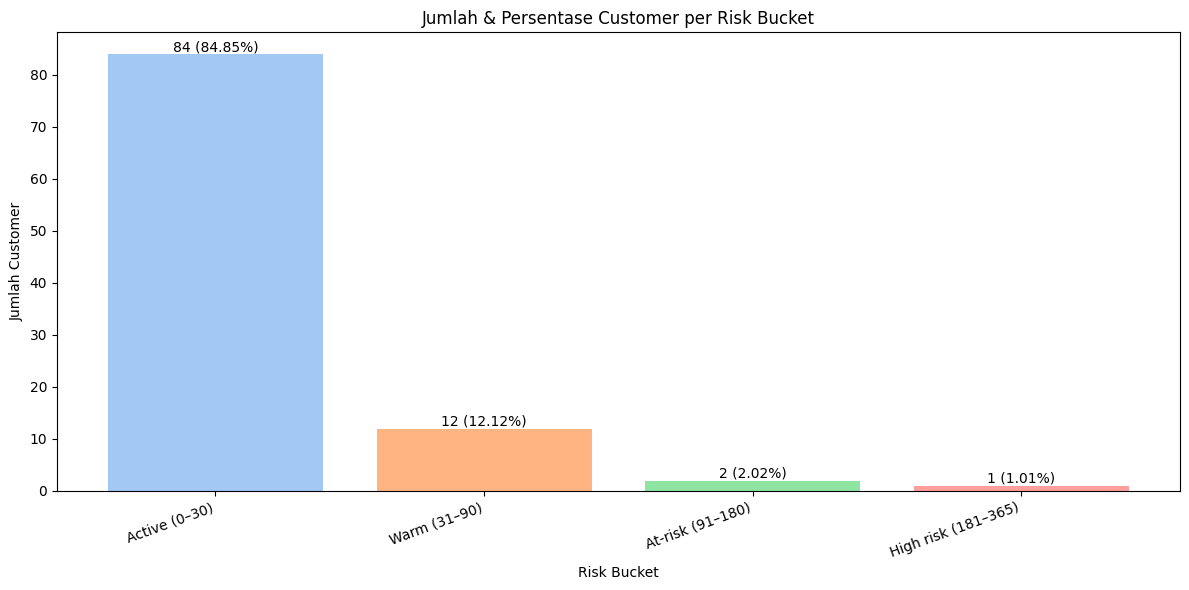

,risk_bucket,customer_count,customer_pct
0,Active (0–30),84,84.85
1,Warm (31–90),12,12.12
2,At-risk (91–180),2,2.02
3,High risk (181–365),1,1.01


In [121]:
# Tentukan urutan kategori risk bucket agar tampil rapi (dari paling aktif sampai paling berisiko)
bucket_order = ["Active (0–30)", "Warm (31–90)", "At-risk (91–180)", "High risk (181–365)"]

# Hitung jumlah customer per kategori risk_bucket
# - value_counts() menghitung frekuensi tiap kategori
# - reindex(bucket_order, fill_value=0) memastikan urutan sesuai bucket_order
#   dan jika ada kategori yang tidak muncul, tetap ditampilkan dengan nilai 0
bucket_counts = (cust["risk_bucket"]
                 .value_counts()
                 .reindex(bucket_order, fill_value=0))

# Hitung persentase per bucket
total_customers = bucket_counts.sum()
bucket_pct = (bucket_counts / total_customers * 100).round(2)

#visualisasi
plt.figure(figsize=(12,6))
palette = sns.color_palette("pastel", n_colors=len(bucket_order))
bars = plt.bar(bucket_counts.index, bucket_counts.values, color=palette)

plt.title("Jumlah & Persentase Customer per Risk Bucket")
plt.xlabel("Risk Bucket")
plt.ylabel("Jumlah Customer")
plt.xticks(rotation=20, ha="right")

# Label: "count (xx.xx%)"
for i, b in enumerate(bars):
    count = int(bucket_counts.iloc[i])
    pct = bucket_pct.iloc[i]
    plt.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{count} ({pct:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# (Opsional) Tampilkan tabel ringkas count + %
summary_bucket = pd.DataFrame({
    "risk_bucket": bucket_counts.index,
    "customer_count": bucket_counts.values,
    "customer_pct": bucket_pct.values
})
summary_bucket

Kita telah membuat fitur baru pada level pelanggan, yaitu `last_purchase`, `recency_days`, dan `risk_bucket`, yang dihitung berdasarkan kolom `Order Date` dan dikelompokkan per `Customer ID` untuk mengukur jarak waktu sejak transaksi terakhir. Berdasarkan visualisasi distribusi risk bucket, mayoritas pelanggan masih berada pada kategori Active (0–30 hari) dan Warm (31–90 hari), namun terdapat 3 pelanggan yang masuk kategori berisiko (recency > 90 hari), yaitu 1 customer pada kategori High risk (181–365) dan 2 customer pada kategori At-risk (91–180). Kelompok ini perlu menjadi prioritas tindak lanjut bagi tim Customer Success/Customer Service agar dilakukan follow-up lebih awal sebelum risiko tidak melakukan renewal semakin tinggi.

Selanjutnya, untuk memahami siapa pelanggan yang paling berisiko dan seberapa besar nilai bisnis yang berpotensi terdampak, kita akan melihat Top 10 pelanggan dengan recency tertinggi (paling lama tidak bertransaksi). Setelah itu, kita hitung nilai Sales dan Profit dalam 12 bulan terakhir (trailing 12 months) untuk masing-masing pelanggan tersebut. Analisis ini akan menjawab pertanyaan kedua:

2. Siapa Top 10 pelanggan paling berisiko (recency tertinggi) dan berapa nilai Sales/Profit 12 bulan terakhir mereka?

In [124]:
# Batas waktu trailing 12 bulan dari akhir dataset
# dataset_end = tanggal transaksi terakhir di dataset (patokan "hari ini" dalam data)
# start_12m = 365 hari sebelum dataset_end (periode 12 bulan terakhir)
start_12m = dataset_end - pd.Timedelta(days=365)

# Filter transaksi yang terjadi dalam 12 bulan terakhir
# .copy() agar aman dari SettingWithCopyWarning saat ada modifikasi berikutnya
df_12m = df[df["Order Date"] >= start_12m].copy()

# Agregasi (ringkasan) sales & profit 12 bulan terakhir per customer
# - groupby Customer ID: mengumpulkan transaksi per pelanggan
# - sales_12m: total Sales selama 12 bulan terakhir
# - profit_12m: total Profit selama 12 bulan terakhir
# - orders_12m: jumlah order unik selama 12 bulan terakhir (pakai nunique karena Order ID bisa berulang di line-item)
cust_12m = (df_12m.groupby("Customer ID", as_index=False)
              .agg(sales_12m=("Sales","sum"),
                   profit_12m=("Profit","sum"),
                   orders_12m=("Order ID","nunique")))

# Gabungkan hasil agregasi 12M ke tabel customer summary (cust)
# how="left" -> semua customer di cust tetap ada, meskipun tidak punya transaksi di 12 bulan terakhir
# fillna -> jika customer tidak punya transaksi 12M (NaN), isi dengan 0 agar mudah dianalisis
cust_risk = cust.merge(cust_12m, on="Customer ID", how="left").fillna(
    {"sales_12m":0, "profit_12m":0, "orders_12m":0}
)

# Ambil Top 10 customer paling berisiko berdasarkan recency_days tertinggi
# recency_days besar = semakin lama sejak transaksi terakhir = semakin berisiko
top10 = cust_risk.sort_values("recency_days", ascending=False).head(10)


# Tampilkan kolom-kolom penting untuk menjawab business question #2
# - Customer ID: identitas customer
# - recency_days & risk_bucket: tingkat risiko
# - last_purchase: kapan terakhir transaksi
# - sales_12m, profit_12m, orders_12m: nilai bisnis 12 bulan terakhir
top10[["Customer ID","recency_days","risk_bucket","last_purchase","sales_12m","profit_12m","orders_12m"]]


,Customer ID,recency_days,risk_bucket,last_purchase,sales_12m,profit_12m,orders_12m
19,1020,239,High risk (181–365),2023-05-06,398.493,-113.6456,2
86,1089,117,At-risk (91–180),2023-09-05,6659.707,288.3993,11
59,1061,96,At-risk (91–180),2023-09-26,2115.540,-11.1898,10
76,1079,76,Warm (31–90),2023-10-16,135.450,33.4947,4
39,1041,75,Warm (31–90),2023-10-17,2403.659,-492.7084,5
83,1086,75,Warm (31–90),2023-10-17,1510.539,-191.6821,7
67,1070,61,Warm (31–90),2023-10-31,7791.438,-186.0102,13
80,1083,50,Warm (31–90),2023-11-11,802.696,312.3659,8
41,1043,43,Warm (31–90),2023-11-18,9632.268,86.2933,26
37,1039,43,Warm (31–90),2023-11-18,10498.627,-784.4916,19


-> Dari Top 10 “paling berisiko”, hanya 3 customer yang benar-benar masuk kategori risk (recency > 90 hari):
- 1020 → 239 hari (High risk)
- 1089 → 117 hari (At-risk)
- 1061 → 96 hari (At-risk)
Sisanya berada di kategori Warm (31–90 hari). Artinya banyak customer di Top 10 ini masih “bisa diselamatkan” dengan follow-up cepat sebelum melewati 90 hari.

-> **Customer 1020** — High risk, recency 239 hari
- Sangat lama tidak transaksi (paling tinggi recency).
- Sales_12M rendah (≈ 398) dan Profit_12M negatif (≈ -114) dengan order sedikit

Interpretasi bisnis:

1. Ini tipe customer yang sudah “dingin” lama + kontribusi bisnis kecil dan bahkan rugi dalam 12 bulan terakhir.
2. Follow-up tetap perlu (untuk konfirmasi status), tetapi dari sisi prioritas nilai bisnis, ini bukan yang terbesar.

-> **Customer 1089** — At-risk, recency 117 hari
- Sales_12M cukup besar (≈ 6.659) dan Profit_12M positif (≈ 288), orders 11.

Interpretasi bisnis:
1. Ini high-potential save: masih punya nilai bisnis baik, tetapi mulai menjauh.
2. Kalau dibiarkan lewat 180 hari, bisa naik ke High risk.

-> **Customer 1061** — At-risk, recency 96 hari
- Sales_12M menengah (≈ 2.116), tapi Profit_12M negatif (≈ -11), orders 10.

Interpretasi bisnis:
- Customer ini masih transaksi cukup sering, tapi margin tipis/negatif.
- Potensi “churn” bisa dipicu oleh pengalaman layanan/produk, tetapi dari sisi perusahaan juga perlu menjaga profitabilitas.

-> **Customer 1041, 1039, 1086, 1070** - Warm dengan sales/profit yang “tidak sehat”. Mereka belum at-risk, tapi bisa jadi “next risk” jika tidak dipantau.

Warm tapi profit negatif besar (red flag profitabilitas)
- 1041: sales_12m ≈ 2.404, profit_12m ≈ -493 (rugi besar)
- 1039: sales_12m ≈ 10.499, profit_12m ≈ -784 (rugi sangat besar)
- 1086: sales_12m ≈ 1.511, profit_12m ≈ -192
- 1070: sales_12m ≈ 7.791, profit_12m ≈ -186

Interpretasi bisnis:
- Mereka masih transaksi (recency 43–75 hari), tapi perusahaan “bayar mahal” untuk revenue itu (profit negatif).
- Ini bukan churn risk langsung, tapi risk profit: kalau renewal terjadi dengan pola diskon/biaya yang sama, perusahaan tetap rugi.

-> **Customer 1083,1043,1079** - Warm dengan profit positif (masih sehat)
- 1083: sales_12m ≈ 803, profit_12m ≈ 312 (profit bagus), recency 50
- 1043: sales_12m ≈ 9.632, profit_12m ≈ 86, orders 26 (tinggi transaksi), recency 43
- 1079: sales_12m ≈ 135, profit_12m ≈ 33, recency 76 (nilai kecil tapi positif)

Interpretasi bisnis:
- Mereka tidak terlalu berisiko saat ini. Namun recency 70–80 hari (contoh 1079) tetap perlu reminder agar tidak lewat 90 hari.


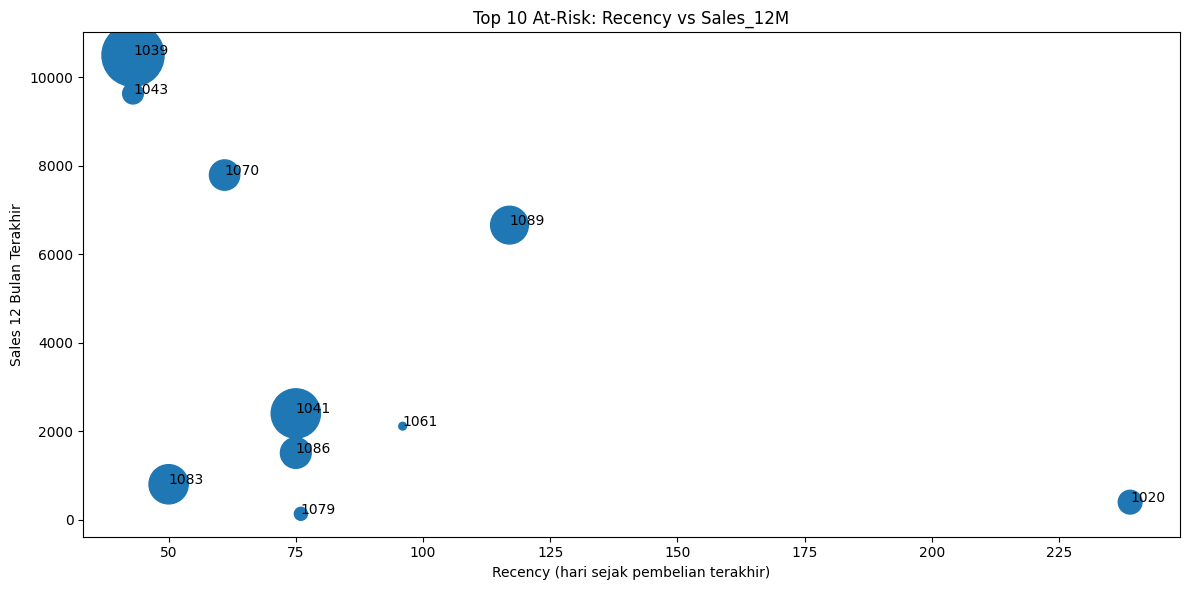

In [126]:
#visualisasi

# Buat salinan data Top 10 agar aman dimodifikasi tanpa mengubah data asli
tmp = top10.copy()

# Ubah Customer ID menjadi string supaya label di plot tampil rapi (tidak dianggap angka)
tmp["Customer ID"] = tmp["Customer ID"].astype(str)

# Tentukan ukuran bubble berdasarkan besar kecilnya profit 12 bulan terakhir
# abs() dipakai agar profit negatif tetap bisa dihitung (ukuran tidak boleh negatif)
# +1 agar tidak ada ukuran bubble = 0
sizes = (tmp["profit_12m"].abs() + 1)

# Normalisasi ukuran bubble agar skala visualnya enak dilihat
# dibagi max -> jadi 0-1, lalu dikali 2000 agar cukup besar terlihat
sizes = sizes / sizes.max() * 2000

plt.figure(figsize=(12,6))

# Scatter plot:
# - sumbu X: recency_days (semakin besar = semakin lama tidak transaksi = semakin berisiko)
# - sumbu Y: sales_12m (nilai bisnis 12 bulan terakhir)
# - ukuran bubble (s): besarnya profit_12m (absolute)
plt.scatter(tmp["recency_days"], tmp["sales_12m"], s=sizes)

# label Customer ID
for _, r in tmp.iterrows():
    plt.text(r["recency_days"], r["sales_12m"], r["Customer ID"])

plt.title("Top 10 At-Risk: Recency vs Sales_12M")
plt.xlabel("Recency (hari sejak pembelian terakhir)")
plt.ylabel("Sales 12 Bulan Terakhir")
plt.tight_layout()
plt.show()


- Semakin ke kanan = recency makin tinggi = makin berisiko.
- Semakin ke atas = sales 12M makin besar = nilai bisnis makin besar.
- Bubble makin besar = |profit| makin besar = dampak profit makin besar (bisa besar karena profit positif besar atau rugi besar).

Makna penting:
- Customer 1089 berada di area “risk tinggi + sales cukup besar” → prioritas retensi.
- Customer 1020 ekstrem di recency tapi kecil nilainya → prioritas validasi status, bukan prioritas revenue.
- Beberapa customer Warm punya bubble besar karena rugi besar (mis. 1039, 1041) → prioritas perbaikan profit/margin, bukan hanya retensi.

* Sales 12M artinya total nilai penjualan (Sales) dalam 12 bulan terakhir.
* Di kode kita, “12 bulan terakhir” dihitung dari tanggal transaksi paling akhir di dataset (`dataset_end`), lalu mundur 365 hari:
- start_12m = `dataset_end` - 365 hari
- lalu kita jumlahkan Sales untuk transaksi yang tanggalnya Order Date >= start_12m

Jadi, untuk setiap `Customer ID`:
- sales_12m = jumlah Sales customer itu selama 12 bulan terakhir (trailing 12 months)
- profit_12m = jumlah Profit customer itu selama 12 bulan terakhir

Selanjutnya, setelah kita mengetahui siapa saja pelanggan yang paling berisiko dan seberapa besar nilai bisnisnya (Sales/Profit 12M), kita perlu melihat risikonya paling banyak muncul di segmen yang mana. Karena itu, pada pertanyaan ketiga ini kita akan menghitung risk rate di tiap Segment (proporsi pelanggan dengan recency > 90 hari), untuk menjawab:

3. Segmen pelanggan mana yang paling rentan (risk rate tertinggi) terhadap penurunan aktivitas/risiko tidak melakukan renewal?

In [ ]:
# Ambil atribut terakhir per customer berdasarkan transaksi terakhirnya
# Tujuan: karena df adalah data transaksi (baris banyak per customer),
# kita butuh 1 baris ringkasan atribut untuk tiap Customer ID agar bisa dianalisis per segmen/wilayah, dll.
attr_cols = ["Segment", "Industry", "Region", "Country", "Product"]

# 1) Urutkan data berdasarkan Order Date (dari lama ke baru)
# 2) groupby Customer ID untuk mengelompokkan transaksi per customer
# 3) ambil nilai "last" (paling akhir) untuk setiap atribut (Segment/Industry/Region/Country/Product)
#    -> ini diasumsikan mewakili atribut customer pada transaksi terakhirnya
#    {c: "last" for c in attr_cols if c in df.columns} memastikan hanya kolom yang benar-benar ada yang diproses
cust_attr = (df.sort_values("Order Date")
               .groupby("Customer ID", as_index=False)
               .agg({c: "last" for c in attr_cols if c in df.columns}))

# Gabungkan tabel atribut (cust_attr) ke tabel ringkasan customer (cust_risk)
# how="left" -> semua customer di cust_risk tetap dipertahankan
# hasilnya cust_full berisi:
# - metrik risk (recency_days, risk_bucket, sales_12m, dll.)
# - atribut customer (Segment, Industry, Region, Country, Product)
cust_full = cust_risk.merge(cust_attr, on="Customer ID", how="left")


In [ ]:
# Hitung risk rate per Segment
# Tujuan: mengetahui segmen pelanggan mana yang paling rentan (proporsi customer berisiko paling tinggi)

risk_by_segment = (cust_full
                   # Kelompokkan data berdasarkan kolom Segment
                   # dropna=False -> jika ada Segment yang kosong/NaN, tetap dihitung sebagai satu kelompok
                   .groupby("Segment", dropna=False)
                   .agg(
                       # customers: jumlah customer unik pada segmen tersebut
                       customers=("Customer ID","nunique"),

                       # risk_customers: jumlah customer berisiko pada segmen tersebut
                       # # is_risk_90+ adalah boolean (True/False), sum() akan menghitung jumlah True
                        risk_customers=("is_risk_90+","sum"),

                        # risk_rate: proporsi customer berisiko pada segmen tersebut
                        # mean() pada boolean menghasilkan rasio True (misal 0.10 = 10%)
                        risk_rate=("is_risk_90+","mean"))

                    # Kembalikan hasil groupby menjadi DataFrame biasa (tidak memakai index Segment)
                   .reset_index())

# Ubah risk_rate dari skala 0–1 menjadi persen (%) dan bulatkan 2 angka di belakang koma
risk_by_segment["risk_rate"] = (risk_by_segment["risk_rate"]*100).round(2)

# Urutkan segmen dari risk rate tertinggi ke terendah agar mudah melihat segmen paling rentan
risk_by_segment = risk_by_segment.sort_values("risk_rate", ascending=False)

# Tampilkan tabel hasil risk rate per segment
risk_by_segment


,Segment,customers,risk_customers,risk_rate
1,SMB,47,3,6.38
0,Enterprise,20,0,0.00
2,Strategic,32,0,0.00


Dari perhitungan risk rate (recency > 90 hari) per segmen:
- SMB: 47 customer, 3 customer risk, risk rate = 6.38%
- Enterprise: 20 customer, 0 customer risk, risk rate = 0%
- Strategic: 32 customer, 0 customer risk, risk rate = 0%
Maka, segmen SMB adalah segmen paling rentan, karena seluruh customer yang masuk kategori risk (recency > 90) berasal dari SMB.

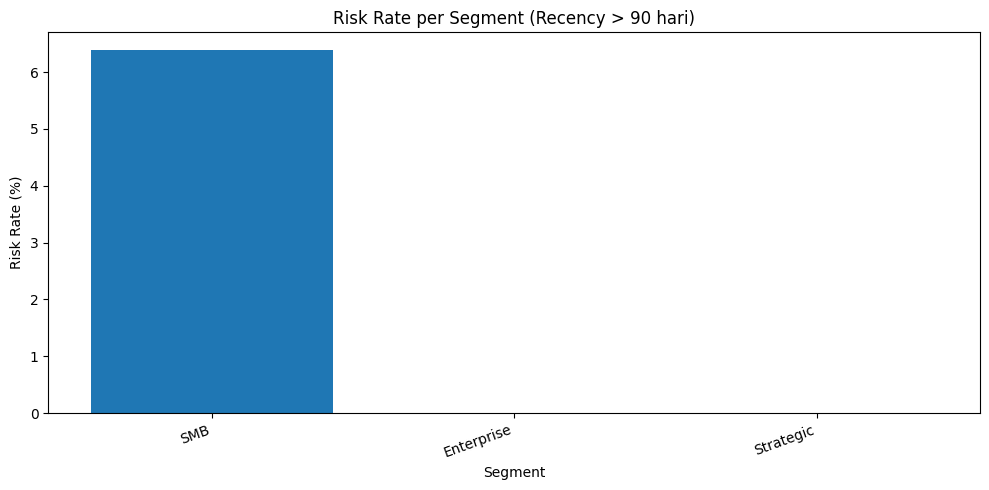

In [130]:
# Membuat ukuran canvas/figure untuk grafik
plt.figure(figsize=(10,5))

# Membuat bar chart:
# - Sumbu X: nama segment (diubah ke string agar aman jika ada nilai non-string/NaN)
# - Sumbu Y: risk_rate (%) pada setiap segment
plt.bar(risk_by_segment["Segment"].astype(str), risk_by_segment["risk_rate"])

# Judul grafik menjelaskan bahwa risk rate dihitung untuk customer dengan recency > 90 hari
plt.title("Risk Rate per Segment (Recency > 90 hari)")

# Label sumbu
plt.xlabel("Segment")
plt.ylabel("Risk Rate (%)")

# Memutar label pada sumbu-x agar tidak bertumpuk dan lebih mudah dibaca
plt.xticks(rotation=20, ha="right")

# Merapikan layout supaya elemen grafik tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()


Hasil analisis menunjukkan bahwa seluruh pelanggan yang masuk kategori risk (recency > 90 hari) berasal dari segmen SMB. Dari total 47 pelanggan SMB, terdapat 3 pelanggan berisiko dengan risk rate 6.38%, sedangkan segmen Enterprise (20 pelanggan) dan Strategic (32 pelanggan) tidak memiliki pelanggan berisiko pada periode data ini (0%). Temuan ini mengindikasikan bahwa segmen SMB lebih rentan mengalami penurunan aktivitas, sehingga perlu menjadi prioritas program retensi dan follow-up lebih dini, khususnya pada pelanggan SMB yang sudah memasuki kategori Warm (31–90 hari).

Selanjutnya, setelah mengetahui bahwa segmen SMB memiliki risk rate tertinggi, kita perlu melihat risiko tersebut terkonsentrasi di wilayah tertentu atau tersebar merata. Karena itu, pada analisis berikutnya kita akan menghitung risk rate berdasarkan Region/Country (proporsi pelanggan dengan recency > 90 hari) untuk menjawab pertanyaan:

4. Wilayah (Region/Country) mana yang paling rentan (risk rate tertinggi) terhadap pelanggan at-risk?

In [131]:
risk_by_region = (cust_full.groupby("Region", dropna=False)
                  .agg(customers=("Customer ID","nunique"),
                       risk_customers=("is_risk_90+","sum"),
                       risk_rate=("is_risk_90+","mean"))
                  .reset_index())

risk_by_region["risk_rate"] = (risk_by_region["risk_rate"]*100).round(2)
risk_by_region = risk_by_region.sort_values("risk_rate", ascending=False)

risk_by_region


,Region,customers,risk_customers,risk_rate
2,EMEA,43,2,4.65
0,AMER,39,1,2.56
1,APJ,17,0,0.00


Region EMEA adalah wilayah paling rentan karena memiliki risk rate tertinggi (4.65%) dan jumlah customer risk terbanyak

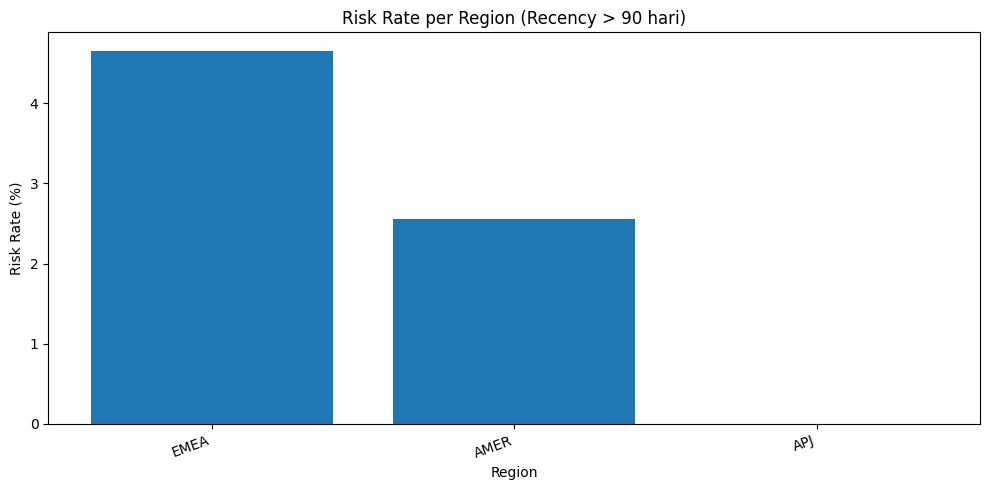

In [132]:
plt.figure(figsize=(10,5))
plt.bar(risk_by_region["Region"].astype(str), risk_by_region["risk_rate"])
plt.title("Risk Rate per Region (Recency > 90 hari)")
plt.xlabel("Region")
plt.ylabel("Risk Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Hasil analisis menunjukkan bahwa region EMEA memiliki tingkat kerentanan tertinggi terhadap pelanggan at-risk, dengan risk rate 4.65% (2 dari 43 customer). Region AMER memiliki risk rate 2.56% (1 dari 39 customer), sedangkan APJ tidak memiliki pelanggan at-risk pada periode data ini (0%). Temuan ini mengindikasikan bahwa penurunan aktivitas pelanggan lebih terkonsentrasi di wilayah EMEA, sehingga wilayah ini dapat menjadi prioritas bagi tim Customer Success/Customer service untuk melakukan monitoring dan follow-up lebih awal, terutama pada segmen yang sebelumnya teridentifikasi paling rentan (SMB).

Selanjutnya, setelah kita mengetahui siapa pelanggan yang berisiko serta segmen dan wilayah yang paling rentan, kita perlu memahami apa perbedaan pola transaksi antara pelanggan berisiko dan pelanggan yang masih aktif. Pada tahap ini, kita akan membandingkan tingkat diskon (avg_discount) dan profit margin (profit_margin) antara dua kelompok, yaitu Active/Warm (recency ≤ 90 hari) dan At-risk/High risk (recency > 90 hari), untuk menjawab pertanyaan:

5. Apakah pelanggan at-risk memiliki pola transaksi berbeda dibanding pelanggan aktif, khususnya pada tingkat diskon dan profit margin?”

In [ ]:
# cek distribusi kolom Profit/Discount
from scipy.stats import normaltest
stats, pval=normaltest(df['Profit'])
if pval<=0.05:
    print('tidak normal') #Ha
else: 
    print('distribusi normal') #Ho 

tidak normal


In [143]:
# cek distribusi kolom Profit/Discount
from scipy.stats import normaltest
stats, pval=normaltest(df['Discount'])
if pval<=0.05:
    print('tidak normal') #Ha
else: 
    print('distribusi normal') #Ho 

tidak normal


In [147]:
# =========================
# UJI INFERENSIAL (NON-PARAMETRIK)
# Mann–Whitney U Test
# Tujuan:
# 1) Menguji apakah distribusi avg_discount berbeda antara grup Active/Warm vs Risk
# 2) Menguji apakah distribusi profit_margin berbeda antara grup Active/Warm vs Risk
# Catatan:
# - Cocok saat data tidak normal / ada outlier
# - Cocok juga ketika ukuran grup tidak seimbang
# =========================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# Pastikan cust_full sudah ada (hasil merge customer summary + atribut)
# Minimal memiliki kolom: avg_discount, profit_margin, recency_days

# Buat label grup:
# Active/Warm  = recency <= 90
# Risk         = recency > 90
cust_full["risk_group"] = np.where(
    cust_full["recency_days"] > 90, 
    "Risk (>90d)", 
    "Active/Warm (<=90d)"
)

# Ambil data per grup (drop NaN supaya uji statistik aman)
active_discount = cust_full.loc[cust_full["risk_group"] == "Active/Warm (<=90d)", "avg_discount"].dropna()
risk_discount   = cust_full.loc[cust_full["risk_group"] == "Risk (>90d)", "avg_discount"].dropna()

active_margin = cust_full.loc[cust_full["risk_group"] == "Active/Warm (<=90d)", "profit_margin"].dropna()
risk_margin   = cust_full.loc[cust_full["risk_group"] == "Risk (>90d)", "profit_margin"].dropna()

# Fungsi bantu untuk menjalankan Mann–Whitney dan merapikan output
def run_mwu(a, b, metric_name):
    # two-sided: menguji ada perbedaan (tanpa asumsi arah)
    stat, p = mannwhitneyu(a, b, alternative="two-sided")

    return {
        "metric": metric_name,
        "n_active": len(a),
        "n_risk": len(b),
        "median_active": float(np.median(a)) if len(a) else np.nan,
        "median_risk": float(np.median(b)) if len(b) else np.nan,
        "mean_active": float(np.mean(a)) if len(a) else np.nan,
        "mean_risk": float(np.mean(b)) if len(b) else np.nan,
        "U_stat": float(stat),
        "p_value": float(p)
    }

# Jalankan uji untuk Avg Discount & Profit Margin
res_discount = run_mwu(active_discount, risk_discount, "avg_discount")
res_margin   = run_mwu(active_margin, risk_margin, "profit_margin")

# Gabungkan hasil dalam tabel
test_results = pd.DataFrame([res_discount, res_margin])

# Tambahkan keputusan uji (alpha = 0.05)
alpha = 0.05
test_results["decision"] = np.where(
    test_results["p_value"] <= alpha,
    "Tolak H0 (berbeda signifikan)",
    "Gagal menolak H0 (tidak signifikan)"
)

test_results


,metric,n_active,n_risk,median_active,median_risk,mean_active,mean_risk,U_stat,p_value,decision
0,avg_discount,96,3,0.158489,0.198101,0.155596,0.207957,14.0,0.008207,Tolak H0 (berbeda signifikan)
1,profit_margin,96,3,0.128785,0.090989,0.120042,0.109710,164.0,0.706743,Gagal menolak H0 (tidak signifikan)


In [148]:
alpha = 0.05
for _, row in test_results.iterrows():
    print(f"Metric: {row['metric']}")
    print(f"p-value: {row['p_value']:.6f}")
    if row["p_value"] <= alpha:
        print("Keputusan: Tolak H0 (ada perbedaan signifikan)\n")
    else:
        print("Keputusan: Gagal menolak H0 (belum ada bukti perbedaan)\n")


Metric: avg_discount
p-value: 0.008207
Keputusan: Tolak H0 (ada perbedaan signifikan)

Metric: profit_margin
p-value: 0.706743
Keputusan: Gagal menolak H0 (belum ada bukti perbedaan)



Uji Mann–Whitney menunjukkan bahwa terdapat perbedaan signifikan pada avg_discount antara grup Active/Warm dan grup Risk (p = 0.008). Namun, untuk profit_margin tidak ditemukan perbedaan signifikan (p = 0.707). Ini mengindikasikan bahwa risiko penurunan aktivitas lebih berkaitan dengan pola diskon, sementara perbedaan profit margin belum terbukti pada data ini.

Dengan demikian, perbedaan pola transaksi antara pelanggan at-risk dan aktif pada dataset ini lebih terlihat pada tingkat diskon, sementara perbedaan profitabilitas (profit margin) belum terbukti secara statistik.

# **Kesimpulan & Rekomendasi**

**Kesimpulan**
1. Distribusi risiko.
Mayoritas pelanggan masih berada di kategori Active (0–30) dan Warm (31–90), namun ada 3 pelanggan berisiko (recency > 90): 2 At-risk (91–180) dan 1 High risk (181–365). Artinya, masalah churn belum masif, tetapi sudah ada “early warning” yang harus ditangani cepat.
2. Siapa yang paling berisiko & nilai bisnisnya.
Customer 1089 dan 1061 masuk At-risk dengan nilai Sales 12M (total nilai penjualan (Sales) dalam 12 bulan terakhir) yang masih ada (masih bernilai untuk diselamatkan). Customer 1020 masuk High risk tetapi nilai bisnis 12M rendah dan profit negatif, sehingga lebih cocok untuk verifikasi/reaktivasi cepat (bukan prioritas revenue utama).
Selain itu, beberapa customer “Warm” punya profit 12M negatif besar → bukan risk churn langsung, tapi risk profitabilitas.
3. Segmen paling rentan.
Seluruh customer risk berasal dari segmen SMB dengan risk rate 6.38%. Enterprise & Strategic 0% pada data ini. Fokus pencegahan paling relevan adalah SMB.
4. Wilayah paling rentan.
Region EMEA memiliki risk rate tertinggi (4.65%) dibanding AMER (2.56%) dan APJ (0%). Artinya risiko lebih terkonsentrasi di EMEA.
5. Apakah pola transaksi berbeda?
Uji Mann–Whitney menunjukkan avg_discount berbeda signifikan antara grup Active/Warm vs Risk (p = 0.008). Namun profit_margin tidak berbeda signifikan (p = 0.707). Ini mengindikasikan faktor diskon lebih terkait dengan risiko penurunan aktivitas dibanding margin (pada dataset ini).

**Rekomendasi untuk stakeholders**
1) Buat “Watchlist At-Risk” sebagai workflow rutin (mingguan)
- Prioritas 1 (Risk + nilai bisnis): customer At-risk dengan Sales_12M tinggi (contoh: 1089, 1061).
- Prioritas 2 (High risk): customer seperti 1020 → lakukan verifikasi cepat status (apakah masih aktif, pindah vendor, atau tidak butuh lagi).
- Output wajib: daftar customer + recency + sales/profit 12M + PIC (CSM/AM) + status follow-up.

** Watchlist At-Risk itu artinya daftar pantauan pelanggan yang berisiko (early warning) untuk segera ditindaklanjuti oleh tim stakeholders

2) Terapkan strategi follow-up berbeda per risk bucket (playbook)
- Warm (31–90): reminder & nurturing (email/WA/call ringan), cek kebutuhan, tawarkan onboarding/fitur yang belum dipakai. Target: cegah melewati 90 hari.
- At-risk (91–180): outreach aktif (call), identifikasi hambatan (budget, usage, kompetitor), ajukan rencana renewal/penyesuaian paket.
- High risk (181–365): reaktivasi singkat + keputusan cepat (win-back offer / close-lost).

3) Fokuskan effort retensi pada SMB di EMEA
Karena risk terkonsentrasi di Segmen SMB dan Region EMEA, alokasikan resource:
- campaign khusus SMB EMEA (check-in, webinar singkat, success plan)
- prioritas CSM/AM untuk akun SMB EMEA yang recency > 60 hari (early warning sebelum 90).

4) Evaluasi kebijakan diskon (karena diskon terbukti terkait risiko)
Karena avg_discount berbeda signifikan antara grup aktif dan risk:
- buat guardrail diskon renewal (mis. diskon maksimal X% tanpa approval)
- diskon jangan jadi “default solusi”; dorong value-based renewal (bundle fitur, support, training)
- pantau customer dengan diskon tinggi tapi mulai warm → “warning flag”.


Analisis ini sudah dapat mengidentifikasi pelanggan at-risk lebih awal menggunakan pendekatan recency (hari sejak transaksi terakhir) dan mengelompokkan pelanggan ke dalam risk bucket. Karakteristik pelanggan berisiko pada dataset ini lebih terkonsentrasi pada segmen SMB dan region EMEA. Dari sisi pola transaksi, tingkat diskon (avg_discount) terbukti berbeda signifikan antara pelanggan aktif dan pelanggan berisiko, sedangkan profit margin belum menunjukkan perbedaan signifikan.

In [150]:
df.head()

,Row ID,Order ID,Order Date,Date Key,Contact Name,Country,City,Region,Subregion,Customer,...,Discount,Profit,last_purchase_x,recency_days_x,risk_bucket_x,is_risk_90+_x,last_purchase_y,recency_days_y,risk_bucket_y,is_risk_90+_y
0,1,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,0.00,41.9136,2023-12-27,4,Active (0–30),False,2023-12-27,4,Active (0–30),False
1,2,EMEA-2022-152156,2022-11-09,20221109,Nathan Bell,Ireland,Dublin,EMEA,UKIR,Chevron,...,0.00,219.5820,2023-12-27,4,Active (0–30),False,2023-12-27,4,Active (0–30),False
2,3,AMER-2022-138688,2022-06-13,20220613,Deirdre Bailey,United States,New York City,AMER,NAMER,Phillips 66,...,0.00,6.8714,2023-12-19,12,Active (0–30),False,2023-12-19,12,Active (0–30),False
3,4,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,0.45,-383.0310,2023-12-29,2,Active (0–30),False,2023-12-29,2,Active (0–30),False
4,5,EMEA-2021-108966,2021-10-11,20211011,Zoe Hodges,Germany,Stuttgart,EMEA,EU-WEST,Royal Dutch Shell,...,0.20,2.5164,2023-12-29,2,Active (0–30),False,2023-12-29,2,Active (0–30),False


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9994 non-null   int64         
 1   Order ID         9994 non-null   object        
 2   Order Date       9994 non-null   datetime64[ns]
 3   Date Key         9994 non-null   int64         
 4   Contact Name     9994 non-null   object        
 5   Country          9994 non-null   object        
 6   City             9994 non-null   object        
 7   Region           9994 non-null   object        
 8   Subregion        9994 non-null   object        
 9   Customer         9994 non-null   object        
 10  Customer ID      9994 non-null   int64         
 11  Industry         9994 non-null   object        
 12  Segment          9994 non-null   object        
 13  Product          9994 non-null   object        
 14  License          9994 non-null   object 